<a href="https://colab.research.google.com/github/pollyyyu/biphasic_application_examples/blob/main/Example%205.4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulation and plot for GRN example with no IFFL

In [1]:
!pip install tellurium

In [2]:
import tellurium as te

import numpy as np
from numpy.linalg import matrix_rank
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm

from mpl_toolkits import mplot3d

import numpy as np
import io
import os
import pandas as pd

rgb_orange = (255, 95, 5)
rgb_blue = (0, 159, 212)
rgb_harvest = (252, 179, 22)

rgb_orange_norm = tuple(c / 255.0 for c in rgb_orange)
rgb_blue_norm = tuple(c / 255.0 for c in rgb_blue)
rgb_harvest_norm = tuple(c / 255.0 for c in rgb_harvest)


In [4]:
tfinal = 100;
n_timestep = 8000;
umin = 0
umax = 0.28
usteps = 100;

err_tol = 1e-6;

no_of_species = 3;
no_of_rxns = 7;
u_array = np.linspace(umin,umax,usteps);
x_output_array = np.zeros(len(u_array))
y_output_array = np.zeros(len(u_array))
z_output_array = np.zeros(len(u_array))

ss_error_array = np.zeros(len(u_array))
evals_output_array = np.zeros((no_of_species,len(u_array)), dtype=complex)

tfinal_relaxation = 500;

ant_str = """
    species x, y, z

    Jx:  -> x; u - d1*x;
    Jy:  -> y; c2 - d2*y;
    Jz:  -> z; c3 - d3*z;

    J1: -> x; k1/(V1+y^n1);
    J2: -> y; k2*x^n2/(V2+x^n2);
    J2i: -> y; k3/(V3+z^n3);
    J3: -> z; k4/(V4+y^n4);

    u = 0;
    c2 = 0.02;
    c3 = 0.02;
    d1 = 1;
    d2 = 0.1;
    d3 = 0.1;

    k1 = 1;
    V1 = 1;
    n1 = 4;

    k2 = 1;
    V2 = 10;
    n2 = 4;

    k3 = 0.5;
    V3 = 3;
    n3 = 2;

    k4 = 0.5;
    V4 = 1;
    n4 = 5;

"""

r = te.loada(ant_str)
X_ids = ['x', 'y', 'z']
x_prev = 0;
y_prev = 0;
z_prev = 0;
X_prev = [x_prev, y_prev, z_prev]

for ii in range(len(u_array)):


  ## setting initial conditions
  r.reset()
  r.u = u_array[ii]
  r.x = x_prev
  r.y = y_prev
  r.z = z_prev


  ## run simulation and save final data
  results = r.simulate(0,tfinal,n_timestep)

  # #double check steady states
  species_list = results.colnames[1:]
  ss_values = results[-1, 1:]
  r.steadyState()
  r.getFloatingSpeciesConcentrations()
  r.getReactionRates()
  r.steadyStateSelections = species_list
  error = np.linalg.norm(r.getSteadyStateValues() - ss_values)/no_of_species
  ss_error_array[ii] = error;
  if error > err_tol:
    results = r.simulate(0,tfinal_relaxation,n_timestep)
    ss_values = results[-1, 1:]

    r.steadyState()
    r.getFloatingSpeciesConcentrations()
    r.getReactionRates()
    r.steadyStateSelections = species_list
    error = np.linalg.norm(r.getSteadyStateValues() - ss_values)/no_of_species
    if error > err_tol:
        print('Current u value = ', u_array[ii])
        print('ss values read from results: ', ss_values)
        print('ss values from getSteadyStateValues: ', r.getSteadyStateValues())
        raise RuntimeError(f'Steady state not reached: error = {error:.3e} > tol = {err_tol:.1e}')

  # save steady state data
  x_output_array[ii] = r.x
  y_output_array[ii] = r.y
  z_output_array[ii] = r.z

  x_prev = r.x;  ## update for next run
  y_prev = r.y;
  z_prev = r.z;
  X_prev = [x_prev, y_prev, z_prev]

  # save eigenvalues data
  evals_output_array[:,ii] = np.linalg.eigvals(r.getReducedJacobian())



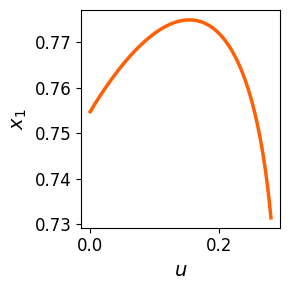

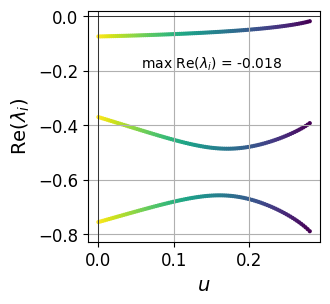

In [5]:
##  x steady state response curve:
fig, ax = plt.subplots(figsize=(3,3))
plt.plot(u_array, x_output_array, color=rgb_orange_norm,  linestyle='-', linewidth=2.5)
plt.xlabel('$u$', fontsize=14)
plt.ylabel('$x_1$', fontsize=14)
ax.tick_params(axis="both", labelsize=12)
# plt.legend(fontsize=12)
plt.tight_layout()
plt.show()





## eigenvalue plots:
fig, ax = plt.subplots(figsize=(3,3))
U = np.tile(u_array, no_of_species)

plt.scatter(U, np.real(evals_output_array), c=U,cmap='viridis_r', s=4)
plt.grid(True)
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
plt.xlabel('$u$', fontsize=14)
plt.ylabel(r'Re($\lambda_i$)', fontsize=14)
plt.tick_params(axis="both", labelsize=12)

ev = evals_output_array.ravel()
max_re = np.max(ev.real)
ax.annotate(rf'max Re($\lambda_i$) = {max_re:.3g}', xy=(0.15, -0.24),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=10);
plt.show()